In [1]:
import pandas as pd
import scipy.stats as stats
from math import sqrt

In [3]:
cars = pd.read_csv('/content/drive/MyDrive/dataset/cars.csv')

In [4]:
cars.head(2)

,Make,Model,Type,Origin,DriveTrain,MSRP,Invoice,EngineSize,Cylinders,Horsepower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,36945.0,33337.0,3.5,6.0,265.0,17.0,23.0,4451.0,106.0,189.0
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,23820.0,21761.0,2.0,4.0,200.0,24.0,31.0,2778.0,101.0,172.0


## **Statement**: Sedan cars cost on an average more than 75000 irrespective of the brand




## **Step 1: Construction of Hypothesis**

Option 1:

$ H_0: \mu >= 75000 $

$ H_a: \mu  < 75000 $

**Conclusion**:
- Sedan cars cost on an average is equals or more than 75000 irrespective of the brand
- Sedan cars cost on an average is less than 75000 irrespective of the brand



Option 2:

$ H_0: \mu <= 75000 $

$ H_a: \mu  > 75000 $


**Conclusion**:
- Sedan cars cost on an average more than 75000 irrespective of the brand
- Sedan cars do not cost on an average more than 75000 irrespective of the brand



## **Step 2: Choose the level of significance**

at $\alpha = 0.05$

## **Step 3: Choose the  test**

- 1 sample t test
- one tailed - Right tail test

## **Step 4: Performing the test**

In [6]:
sample = cars.loc[cars['Type']=='Sedan', 'MSRP']
mu0 = 750000

```python
stats.ttest_1samp(sample, popmean=mu0, alternative={'greater' # for right tail
                                                    'less' # for left tail
                                                    'two-sided # two tail test
                                                    })
```

In [8]:
t_stats, p_value = stats.ttest_1samp(sample, popmean=mu0, alternative='greater')

In [12]:
print(f"The test statistic is: {t_stats:7.2f}")
print(f"The p-value is       : {p_value:7.2f}")

The test statistic is: -748.04
The p-value is       :    1.00


## **Step 5: Conclusion**

In [13]:
def conclude(p_value, alpha = 0.05):
  if p_value < alpha:
    print("Reject the null hypothesis")
  else:
    print("Fail to reject the null hypothesis")

In [14]:
conclude(p_value)

Fail to reject the null hypothesis


<font size = 6> **Conclusion:**
<font size = 4>

**Sedan cars do not cost on an average more than 75000 irrespective of the brand**

## **Statement**: The mileage of Sedan cars is not better than SUV cars on Highway




## **Step 1: Construction of Hypothesis**

$ H_0: \mu_{Sedan} - \mu_{SUVs} <= 0 $

$ H_a: \mu_{Sedan} - \mu_{SUVs}  > 0 $


**Conclusion**:
- The mileage of Sedan cars is not better than SUV cars on Highway
- The mileage of Sedan cars is better than SUV cars on Highway



## **Step 2: Choose the level of significance**

at $\alpha = 0.05$

## **Step 3: Choose the  test**

- 2 sample independent t test
- Right tailed

## **Step 4: Performing the test**

In [15]:
sample_1 = cars.loc[cars['Type']=='Sedan', 'MPG_Highway']
sample_2 = cars.loc[cars['Type']=='SUV', 'MPG_Highway']

```python
stats.ttest_ind(sample1, sample2)
```

In [16]:
t_stats, p_value = stats.ttest_ind(sample_1, sample_2, alternative='greater')

In [17]:
print(f"The test statistic is: {t_stats:7.2f}")
print(f"The p-value is       : {p_value:7.2f}")

The test statistic is:   13.27
The p-value is       :    0.00


## **Step 5: Conclusion**

In [18]:
conclude(p_value)

Reject the null hypothesis


- The mileage of Sedan cars is better than SUV cars on Highway

In [21]:
sample_1.var()

19.95819075195226

In [22]:
sample_2.var()

11.135593220338983

In [23]:
stats.ttest_ind(sample_1, sample_2, alternative='greater', equal_var = False)

TtestResult(statistic=np.float64(15.889812517482019), pvalue=np.float64(6.945684844262986e-31), df=np.float64(113.06651978010669))

In [24]:
stats.ttest_ind(sample_1, sample_2, alternative='greater', equal_var = True)

TtestResult(statistic=np.float64(13.26714138421889), pvalue=np.float64(1.3034344540849366e-32), df=np.float64(320.0))

In [38]:
# calculate trimmed variance
var1 = stats.tvar(sample_1)
var2 = stats.tvar(sample_2)

# calculate the F stats
F = var1/var2

# get the numerator and denominator degrees of freedom
df1 = len(sample_1) - 1
df2 = len(sample_2) - 1

# for p value = 2 * min(left tail p value, right tail p value)

left_tail = stats.f.cdf(F,  df1, df2 )
right_tail = 1 - stats.f.cdf(F,  df1, df2 )

p_value = min( left_tail, right_tail) * 2

conclude(p_value) # rehect means that var is not equal

Reject the null hypothesis


In [39]:
t_test, p_vlaue = stats.ttest_ind(sample_1, sample_2, alternative='greater', equal_var = False)

In [40]:
conclude(p_value)

Reject the null hypothesis


## **Statement: (Sample_data.csv)**
Math1 and Math2
Assuming
Math1 is score before a special class
Math2 is score after a special class.

Did this special class help change the score?

$H_0 : \mu (Math2 - Math1)  = 0$

$H_a : \mu (Math2 - Math1) != 0$

-- paired 2 sample

In [41]:
sample_data = pd.read_csv('/content/drive/MyDrive/dataset/Sample_data.csv')

In [43]:
sample_1 = sample_data['Math1']
sample_2 = sample_data['Math2']

In [45]:
t, p = stats.ttest_rel(sample_1, sample_2, alternative='two-sided')

In [46]:
conclude(p)

Fail to reject the null hypothesis


ANOVA: more than 2 samples

In [47]:
# the price of Sedan cars for top 6 makes is same

In [49]:
top_6_makes = cars['Make'].value_counts()[:6].index
top_6_makes

Index(['Toyota', 'Chevrolet', 'Mercedes-Benz', 'Ford', 'BMW', 'Audi'], dtype='object', name='Make')

In [57]:
subdata = cars[cars['Make'].isin(top_6_makes)]
subdata = subdata[subdata['Type'] == 'Sedan']

In [58]:
from statsmodels.formula.api import ols # linear regression
from statsmodels.stats.anova import anova_lm # anova table

formula ->

Variable ~ Treatment

Variable : the variable of interest | the one we are comparing - Price

Treatment : categorical or the group column - Make

In [59]:
formula = 'MSRP ~ Make'

# develop a linear model
model = ols(formula = 'MSRP ~ Make', data = subdata).fit()

# get teh anova results:
anova_results = anova_lm(model)

anova_results

,df,sum_sq,mean_sq,F,PR(>F)
Make,5.0,1.623173e+10,3.246346e+09,14.715584,3.773020e-10
Residual,78.0,1.720726e+10,2.206060e+08,NaN,NaN


Conclusion: Atleast 1 is different
Which one or more?

Multiple t test

H0 the pair in question has similar mean

Ha : the pair in question has different measn

In [60]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [61]:
results = pairwise_tukeyhsd(subdata['MSRP'], subdata['Make'])

In [62]:
display(results.summary())

group1,group2,meandiff,p-adj,lower,upper,reject
Audi,BMW,2271.9231,0.9988,-14749.5387,19293.3849,False
Audi,Chevrolet,-20621.0256,0.0058,-37065.32,-4176.7313,True
Audi,Ford,-20272.2378,0.0161,-38050.5748,-2493.9008,True
Audi,Mercedes-Benz,13465.2452,0.1595,-2738.7037,29669.1941,False
Audi,Toyota,-20847.6923,0.0043,-37051.6412,-4643.7434,True
BMW,Chevrolet,-22892.9487,0.0015,-39337.2431,-6448.6544,True
BMW,Ford,-22544.1608,0.0051,-40322.4978,-4765.8238,True
BMW,Mercedes-Benz,11193.3221,0.3416,-5010.6267,27397.271,False
BMW,Toyota,-23119.6154,0.0011,-39323.5642,-6915.6665,True
Chevrolet,Ford,348.7879,1.0,-16877.7592,17575.3349,False


reject = True |Null is rejected | pair is different

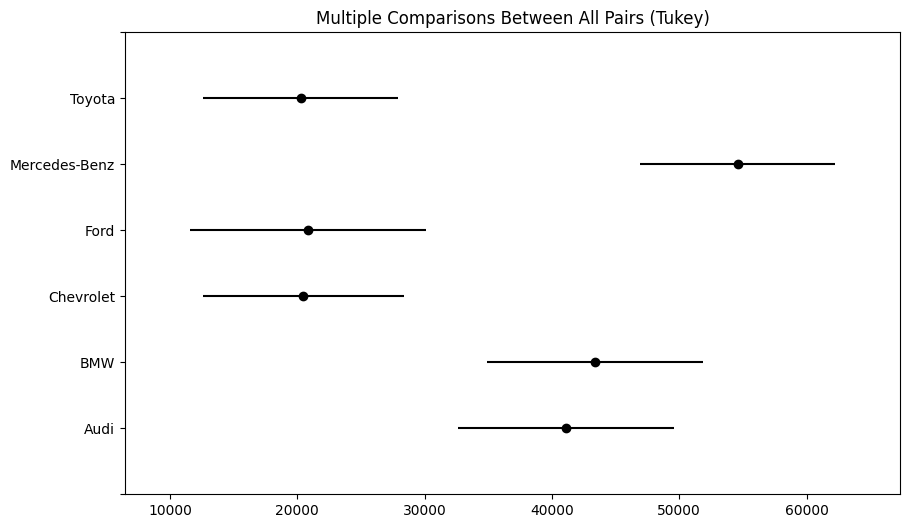

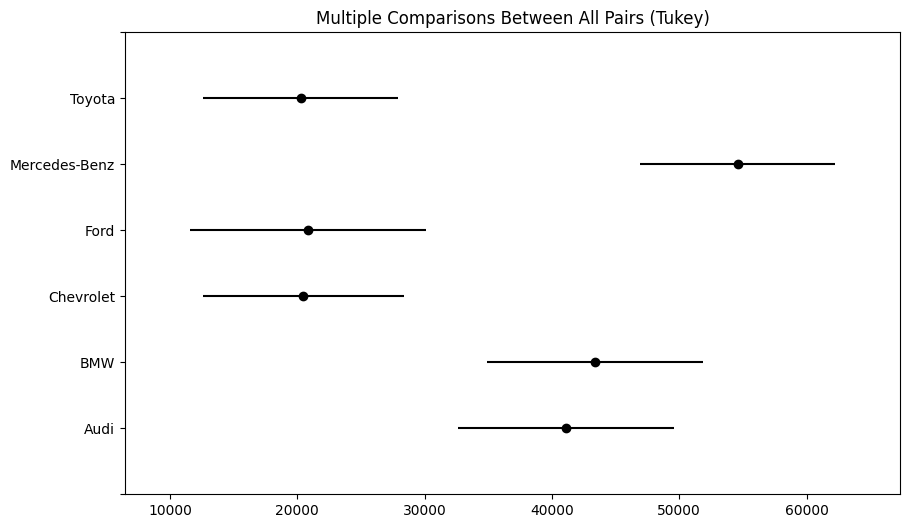

In [63]:
results.plot_simultaneous()